#### Dependencies

In [932]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lifelines import KaplanMeierFitter, CoxPHFitter, NelsonAalenFitter
from sklearn.model_selection import KFold
from scipy.stats import gaussian_kde, norm
from sklearn.model_selection import train_test_split
from matplotlib.ticker import FuncFormatter
from lifelines.plotting import add_at_risk_counts
from lifelines.utils import concordance_index

import statsmodels.api as sm

from __future__ import annotations
from collections import Counter
from dataclasses import dataclass
import hashlib
import warnings
warnings.filterwarnings("ignore")

from dataclasses import dataclass
from typing import Optional, List, Dict, Tuple

from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score

from lifelines.statistics import logrank_test

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None) 

#### Datasets

In [933]:
lical0 = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFile/lical0_processed_data_for_fp_model_21-01-2026.csv')
miro0 = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFile/miro0_processed_data_for_fp_model_21-01-2026.csv')
ril_3010 = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFile/ril_3010_processed_data_for_fp_model_21-01-2026.csv')

# miroli0 = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFile/miroli0_processed_data_for_fp_model_21-01-2026.csv')
proact0 = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFile/proact0_processed_data_for_fp_model_21-01-2026.csv')

MND_lica = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFIle/MNDRegisterDataset_licals.csv')
MND_miro = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFIle/MNDRegisterDataset_mirocals.csv')
MND_rilu = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFIle/MNDRegisterDataset_riluzole.csv')

In [934]:
proact0 = proact0[proact0['Disease_Duration'] < 120]

##### Proact with eligibility criteria

In [935]:
proact_miro = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFIle/proact_miro_full.csv')
proact_lica = pd.read_csv('/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/DataFIle/proact_lica_full.csv')

proact_miro['slope'] = (48 - proact_miro['ALSFRS_RT']) / proact_miro['Disease_Duration']
proact_lica['slope'] = (48 - proact_lica['ALSFRS_RT']) / proact_lica['Disease_Duration']

binss = [-np.inf, 0.31, 1.17, np.inf]
labelss = ["Slow", "Intermediate", "Fast"]

proact_miro["Progression_group"] = pd.cut(proact_miro["slope"], bins=binss, labels=labelss)
proact_lica["Progression_group"] = pd.cut(proact_lica["slope"], bins=binss, labels=labelss)


proact_miro['Study_Arm_Placebo'] = (proact_miro['Study_Arm'] == 'Placebo').astype(int)
proact_lica['Study_Arm_Placebo'] = (proact_lica['Study_Arm'] == 'Placebo').astype(int)

proact_miro = proact_miro[['subject_id', 'Event', 'Vital_Capacity_l_std', 'Sex_Male', 'Onset_Limb', 'Study_Arm_Placebo', 'Age_std', 'Diagnosis_delay_l_std', 'Disease_Duration', 'TRICALS', 'Sex_onset',	'Age_Sex', 'Age_onset', 'Age_sq', "Progression_group"]]
proact_lica = proact_lica[['subject_id', 'Event', 'Vital_Capacity_l_std', 'Sex_Male', 'Onset_Limb', 'Study_Arm_Placebo', 'Age_std', 'Diagnosis_delay_l_std', 'Disease_Duration', 'TRICALS', 'Sex_onset',	'Age_Sex', 'Age_onset', 'Age_sq', "Progression_group"]]

proact_miro = proact_miro.rename(columns={'Age_std': 'Age', 'Diagnosis_delay_l_std': 'Diagnostic_Delay', 'Vital_Capacity_l_std': 'Vital_capacity'})
proact_lica = proact_lica.rename(columns={'Age_std': 'Age', 'Diagnosis_delay_l_std': 'Diagnostic_Delay', 'Vital_Capacity_l_std': 'Vital_capacity'})


# print(f"proact_miro: {proact_miro.shape} | proact_lica: {proact_lica.shape}")
proact_lica.head(2)

,subject_id,Event,Vital_capacity,Sex_Male,Onset_Limb,Study_Arm_Placebo,Age,Diagnostic_Delay,Disease_Duration,TRICALS,Sex_onset,Age_Sex,Age_onset,Age_sq,Progression_group
0,1333,1,0.257074,0,1,0,-0.428923,0.605487,22.996058,-3.779545,0,-0.000000,-0.428923,0.183975,Fast
1,3350,0,1.381487,1,1,0,1.305237,0.462062,21.747700,-4.907534,1,1.305237,1.305237,1.703642,Intermediate


#### **Select only the treatment arm**

In [936]:
lical0_trt = lical0[lical0['Study_Arm_Placebo'] == 0].copy()
miro0_trt = miro0[miro0['Study_Arm_Placebo'] == 0].copy()
# miroli0_trt = miroli0[miroli0['Study_Arm_Placebo'] == 0].copy()
ril_3010_trt = ril_3010[ril_3010['Study_Arm_Placebo'] == 0].copy()
proact0_trt = proact0[proact0['Study_Arm_Placebo'] == 0].copy() 

#### **Select only the placebo arm**

In [937]:
lical0_pla = lical0[lical0['Study_Arm_Placebo'] == 1].copy()
miro0_pla = miro0[miro0['Study_Arm_Placebo'] == 1].copy()
# miroli0_pla = miroli0[miroli0['Study_Arm_Placebo'] == 1].copy()
ril_3010_pla = ril_3010[ril_3010['Study_Arm_Placebo'] == 1].copy()
proact0_pla = proact0[proact0['Study_Arm_Placebo'] == 1].copy() 

In [938]:
proact_miro_pla = proact_miro[proact_miro['Study_Arm_Placebo'] == 1]
proact_lica_pla = proact_lica[proact_lica['Study_Arm_Placebo'] == 1]

proact_miro_trt = proact_miro[proact_miro['Study_Arm_Placebo'] == 0]
proact_lica_trt = proact_lica[proact_lica['Study_Arm_Placebo'] == 0]

print(f"proact_miro_trt: {proact_miro_trt.shape} | proact_lica_trt: {proact_lica_trt.shape}\n")
print(f"proact_miro_pla: {proact_miro_pla.shape} | proact_lica_pla: {proact_lica_pla.shape}\n")
proact_lica_pla.head(2)

proact_miro_trt: (240, 15) | proact_lica_trt: (346, 15)

proact_miro_pla: (188, 15) | proact_lica_pla: (281, 15)



,subject_id,Event,Vital_capacity,Sex_Male,Onset_Limb,Study_Arm_Placebo,Age,Diagnostic_Delay,Disease_Duration,TRICALS,Sex_onset,Age_Sex,Age_onset,Age_sq,Progression_group
3,4753,1,-0.336316,0,1,1,-1.902391,-1.024997,14.586071,-2.589279,0,-0.0,-1.902391,3.619093,Fast
5,7540,0,0.043730,0,1,1,0.704515,0.685898,20.400788,-4.593248,0,0.0,0.704515,0.496341,Intermediate


In [939]:
print(f"Miro: {miro0_pla.Disease_Duration.describe().round(2).to_dict()}\n")
# print(f"miroli: {miroli0_pla.Disease_Duration.describe().round(2).to_dict()}\n")
print(f"Lical :{lical0_pla.Disease_Duration.describe().round(2).to_dict()}\n")
print(f"Riluzole: {ril_3010_pla.Disease_Duration.describe().round(2).to_dict()}\n")

print(f"Proact: {proact0_pla.Disease_Duration.describe().round(2).to_dict()}\n")

print(f"MND_lica: {MND_lica.Disease_Duration.describe().round(2).to_dict()}\n")
print(f"MND_miro: {MND_miro.Disease_Duration.describe().round(2).to_dict()}\n")
print(f"MND_rilu: {MND_rilu.Disease_Duration.describe().round(2).to_dict()}\n")

Miro: {'count': 110.0, 'mean': 29.04, 'std': 8.09, 'min': 8.05, '25%': 25.14, '50%': 29.35, '75%': 34.32, 'max': 44.92}

Lical :{'count': 87.0, 'mean': 31.76, 'std': 8.63, 'min': 10.86, '25%': 24.95, '50%': 34.81, '75%': 37.67, 'max': 46.14}

Riluzole: {'count': 242.0, 'mean': 13.41, 'std': 5.41, 'min': 0.3, '25%': 9.2, '50%': 15.82, '75%': 17.94, 'max': 20.7}

Proact: {'count': 1547.0, 'mean': 29.64, 'std': 11.36, 'min': 4.66, '25%': 21.83, '50%': 27.9, '75%': 35.41, 'max': 100.1}

MND_lica: {'count': 146.0, 'mean': 23.87, 'std': 7.56, 'min': 7.13, '25%': 18.32, '50%': 24.56, '75%': 30.42, 'max': 35.94}

MND_miro: {'count': 92.0, 'mean': 18.8, 'std': 5.62, 'min': 5.22, '25%': 14.82, '50%': 19.73, '75%': 24.08, 'max': 27.92}

MND_rilu: {'count': 169.0, 'mean': 29.55, 'std': 11.92, 'min': 5.65, '25%': 20.86, '50%': 29.53, '75%': 36.24, 'max': 59.92}



#### Choosing cohorts

In [940]:
MND_lica.columns

Index(['subject_id', 'Event', 'Disease_Duration', 'Age', 'Diagnostic_Delay',
       'Sex_Male', 'Onset_Limb', 'Sex_onset', 'Age_Sex', 'Age_onset', 'Age_sq',
       'TRICALS_Risk_Score'],
      dtype='object')

In [941]:
lical0_trt.columns

Index(['subject_id', 'Event', 'Disease_Duration', 'Study_Arm_Placebo', 'Age',
       'TRICALS', 'Diagnostic_Delay', 'Vital_capacity', 'Onset_Limb',
       'Sex_Male', 'Sex_onset', 'Age_Sex', 'Age_onset', 'Age_TRICALS',
       'Age_VC', 'Sex_VC', 'Onset_VC', 'Age_sq'],
      dtype='object')

In [942]:
MND_miro['Study_Arm_Placebo'] = 1
MND_lica['Study_Arm_Placebo'] = 1

MND_miro = MND_miro.rename(columns={'TRICALS_Risk_Score': 'TRICALS'})
MND_lica = MND_lica.rename(columns={'TRICALS_Risk_Score': 'TRICALS'})

miro0_trt_mnd = miro0_trt[['subject_id', 'Event', 'Disease_Duration','Study_Arm_Placebo', 'Age', 'Diagnostic_Delay',
       'Sex_Male', 'Onset_Limb', 'Sex_onset', 'Age_Sex', 'Age_onset', 'Age_sq', 'TRICALS']]
lical0_trt_mnd = lical0_trt[['subject_id', 'Event', 'Disease_Duration','Study_Arm_Placebo', 'Age', 'Diagnostic_Delay',
       'Sex_Male', 'Onset_Limb', 'Sex_onset', 'Age_Sex', 'Age_onset', 'Age_sq', 'TRICALS']]


miro_trt_trical = miro0_trt[(miro0_trt['TRICALS'] >= -6) & (miro0_trt['TRICALS'] <= -2)]
MND_miro_trical = MND_miro[(MND_miro['TRICALS'] >= -6) & (MND_miro['TRICALS'] <= -2)]

lica_trt_trical = lical0_trt[(lical0_trt['TRICALS'] >= -6) & (lical0_trt['TRICALS'] <= -2)]
MND_lica_trical = MND_lica[(MND_lica['TRICALS'] >= -6) & (MND_lica['TRICALS'] <= -2)]


##### **Propensity score matching**

In [ ]:
# ============================================================
# PROPENSITY SCORE + OVERLAP
# ============================================================
def fit_propensity_score(
    df: pd.DataFrame,
    covariates: List[str],
    penalty: str = "l2",
    C: float = 1.0
) -> Tuple[pd.DataFrame, Pipeline]:
    """
    Logistic PS model: probability of being in treated trial arm.
    Missing numeric values are median-imputed.
    """
    x = df[covariates].copy()
    y = df["Group"].astype(int).values

    numeric_features = covariates
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features)
        ],
        remainder="drop"
    )

    model = LogisticRegression(
        penalty=penalty,
        C=C,
        solver="lbfgs",
        max_iter=5000
    )

    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(x, y)
    ps = pipe.predict_proba(x)[:, 1]

    out = df.copy()
    out["ps"] = ps
    out["ps_logit"] = np.log(np.clip(ps, 1e-6, 1-1e-6) / np.clip(1-ps, 1e-6, 1-1e-6))

    auc = roc_auc_score(y, ps)
    print(f"Propensity model AUC: {auc:.3f}")

    return out, pipe


# Trim non overlapping records
def trim_nonoverlap(df: pd.DataFrame, ps_col: str = "ps") -> pd.DataFrame:
    """
    Trim non-overlapping tails:
      treated above max(control) and control below min(treated)
    """
    x = df.copy()
    ps_t = x.loc[x["Group"] == 1, ps_col]
    ps_c = x.loc[x["Group"] == 0, ps_col]

    lower = ps_t.min()
    upper = ps_c.max()

    # More symmetric overlap region
    lower_common = max(ps_t.min(), ps_c.min())
    upper_common = min(ps_t.max(), ps_c.max())

    trimmed = x[(x[ps_col] >= lower_common) & (x[ps_col] <= upper_common)].copy()

    print(f"Before trimming: {len(x)}")
    print(f"After trimming:  {len(trimmed)}")
    print(f"Removed:         {len(x) - len(trimmed)}")

    return trimmed.reset_index(drop=True)


# make treated and contral groups more comparable
def add_weights(df: pd.DataFrame, method: str = "overlap", ps_col: str = "ps") -> pd.DataFrame:
    """
    Supported:
      - overlap
      - iptw
      - unstabilized
    """
    x = df.copy()
    ps = np.clip(x[ps_col].values, 1e-6, 1 - 1e-6)
    g = x["Group"].values

    if method == "overlap":
        w = np.where(g == 1, 1 - ps, ps)
    elif method in ("iptw", "unstabilized"):
        w = np.where(g == 1, 1 / ps, 1 / (1 - ps))
    else:
        raise ValueError("method must be 'overlap' or 'iptw'")

    x["weight"] = w
    return x



# ============================================================
# BALANCE DIAGNOSTICS
# ============================================================
def weighted_mean(x, w):
    return np.sum(w * x) / np.sum(w)


def weighted_var(x, w):
    mu = weighted_mean(x, w)
    return np.sum(w * (x - mu) ** 2) / np.sum(w)


def smd_continuous(x_t, x_c, w_t=None, w_c=None):
    x_t = np.asarray(x_t, dtype=float)
    x_c = np.asarray(x_c, dtype=float)

    if w_t is None:
        mt = np.nanmean(x_t)
        vt = np.nanvar(x_t, ddof=0)
    else:
        mt = weighted_mean(x_t, w_t)
        vt = weighted_var(x_t, w_t)

    if w_c is None:
        mc = np.nanmean(x_c)
        vc = np.nanvar(x_c, ddof=0)
    else:
        mc = weighted_mean(x_c, w_c)
        vc = weighted_var(x_c, w_c)

    pooled_sd = np.sqrt((vt + vc) / 2)
    if pooled_sd == 0 or np.isnan(pooled_sd):
        return np.nan
    return (mt - mc) / pooled_sd


def smd_binary(x_t, x_c, w_t=None, w_c=None):
    x_t = np.asarray(x_t, dtype=float)
    x_c = np.asarray(x_c, dtype=float)

    if w_t is None:
        pt = np.nanmean(x_t)
    else:
        pt = weighted_mean(x_t, w_t)

    if w_c is None:
        pc = np.nanmean(x_c)
    else:
        pc = weighted_mean(x_c, w_c)

    p = (pt + pc) / 2
    denom = np.sqrt(p * (1 - p))
    if denom == 0 or np.isnan(denom):
        return np.nan
    return (pt - pc) / denom


def balance_table(df: pd.DataFrame, covariates: List[str], weight_col: Optional[str] = None) -> pd.DataFrame:
    rows = []

    treated = df[df["Group"] == 1].copy()
    control = df[df["Group"] == 0].copy()

    for col in covariates:
        xt = treated[col].astype(float)
        xc = control[col].astype(float)

        mask_t = xt.notna()
        mask_c = xc.notna()
        xt = xt[mask_t]
        xc = xc[mask_c]

        wt = treated.loc[mask_t, weight_col].values if weight_col is not None else None
        wc = control.loc[mask_c, weight_col].values if weight_col is not None else None

        uniq = pd.concat([xt, xc]).dropna().unique()
        is_binary = set(np.unique(uniq)).issubset({0.0, 1.0})

        if is_binary:
            smd = smd_binary(xt, xc, wt, wc)
        else:
            smd = smd_continuous(xt, xc, wt, wc)

        if weight_col is None:
            mt = np.nanmean(xt)
            mc = np.nanmean(xc)
        else:
            mt = weighted_mean(xt.values, wt)
            mc = weighted_mean(xc.values, wc)

        rows.append({
            "Variable": col,
            "Treated_mean": mt,
            "Control_mean": mc,
            "SMD": smd,
            "Abs_SMD": np.abs(smd)
        })

    out = pd.DataFrame(rows).sort_values("Abs_SMD", ascending=False).reset_index(drop=True)
    return out


# ============================================================
# SURVIVAL ANALYSIS
# ============================================================
def weighted_km_plot(
    df: pd.DataFrame,
    time_col: str = "Time",
    event_col: str = "Event",
    weight_col: Optional[str] = "weight",
    title: str = "Weighted Kaplan-Meier",
    x_max: Optional[float] = None
):
    plt.figure(figsize=(5, 4))

    km_t = KaplanMeierFitter()
    km_c = KaplanMeierFitter()

    treated = df[df["Group"] == 1].copy()
    control = df[df["Group"] == 0].copy()

    km_t.fit(
        durations=treated[time_col],
        event_observed=treated[event_col],
        weights=treated[weight_col] if weight_col else None,
        label="Treated"
    )
    km_c.fit(
        durations=control[time_col],
        event_observed=control[event_col],
        weights=control[weight_col] if weight_col else None,
        label="External control"
    )

    ax = km_t.plot_survival_function(ci_show=True)
    km_c.plot_survival_function(ci_show=True, ax=ax)

    ax.set_xlabel("Disease Duration")
    ax.set_ylabel("Survival probability")
    ax.set_title(title)
    ax.set_ylim(0,1.02)
    ax.grid(True, alpha=0.3)
    if x_max is not None:
        ax.set_xlim(0, x_max)
    plt.tight_layout()
    plt.show()
    




In [943]:
# combine mirocals treated and licals placebo
comb = pd.concat([lical0_trt, miro0_pla], axis=0, ignore_index=True)
comb['Group'] = (comb['Study_Arm_Placebo'] == 0).astype(int)
comb.shape

(199, 19)

In [944]:
comb.head(2)

,subject_id,Event,Disease_Duration,Study_Arm_Placebo,Age,TRICALS,Diagnostic_Delay,Vital_capacity,Onset_Limb,Sex_Male,Sex_onset,Age_Sex,Age_onset,Age_TRICALS,Age_VC,Sex_VC,Onset_VC,Age_sq,Group
0,P01003,0,34.571616,0,-1.105049,-1.025245,0.017917,0.676193,1,1,1,-1.105049,-1.105049,1.132946,-0.747226,0.676193,0.676193,1.221133,1
1,P01004,0,28.428384,0,-1.059473,-0.706113,-1.452295,0.522667,1,1,1,-1.059473,-1.059473,0.748108,-0.553751,0.522667,0.522667,1.122482,1


In [946]:
covariates = ['Disease_Duration', 'Age', 'Diagnostic_Delay', 'Onset_Limb', 'Sex_Male'] #, 'Vital_capacity']

comb_ps, propen = fit_propensity_score(comb, covariates)
# 
comb_ps.head(2)

Propensity model AUC: 0.618


,subject_id,Event,Disease_Duration,Study_Arm_Placebo,Age,TRICALS,Diagnostic_Delay,Vital_capacity,Onset_Limb,Sex_Male,Sex_onset,Age_Sex,Age_onset,Age_TRICALS,Age_VC,Sex_VC,Onset_VC,Age_sq,Group,ps,ps_logit
0,P01003,0,34.571616,0,-1.105049,-1.025245,0.017917,0.676193,1,1,1,-1.105049,-1.105049,1.132946,-0.747226,0.676193,0.676193,1.221133,1,0.534075,0.136513
1,P01004,0,28.428384,0,-1.059473,-0.706113,-1.452295,0.522667,1,1,1,-1.059473,-1.059473,0.748108,-0.553751,0.522667,0.522667,1.122482,1,0.605368,0.427883


In [ ]:
trim_propen = trim_nonoverlap(comb_ps, "ps")

Before trimming: 199
After trimming:  186
Removed:         13


In [ ]:
comb_weight = add_weights(comb_ps)
comb_weight.head(2)

,subject_id,Event,Disease_Duration,Study_Arm_Placebo,Age,TRICALS,Diagnostic_Delay,Vital_capacity,Onset_Limb,Sex_Male,Sex_onset,Age_Sex,Age_onset,Age_TRICALS,Age_VC,Sex_VC,Onset_VC,Age_sq,Group,ps,ps_logit,weight
0,P01003,0,34.571616,0,-1.105049,-1.025245,0.017917,0.676193,1,1,1,-1.105049,-1.105049,1.132946,-0.747226,0.676193,0.676193,1.221133,1,0.534075,0.136513,0.465925
1,P01004,0,28.428384,0,-1.059473,-0.706113,-1.452295,0.522667,1,1,1,-1.059473,-1.059473,0.748108,-0.553751,0.522667,0.522667,1.122482,1,0.605368,0.427883,0.394632


In [ ]:
# ============================================================
# BALANCE DIAGNOSTICS
# ============================================================
comb_baln = balance_table(comb_weight, covariates, 'weight')
comb_baln

,Variable,Treated_mean,Control_mean,SMD,Abs_SMD
0,Sex_Male,0.702284,0.691706,0.023018,0.023018
1,Diagnostic_Delay,-0.035851,-0.027821,-0.007514,0.007514
2,Onset_Limb,0.803702,0.803234,0.001178,0.001178
3,Age,0.012209,0.011658,0.000529,0.000529
4,Disease_Duration,29.595107,29.594199,0.000102,0.000102


In [951]:
# weighted_km_plot(comb_weight, time_col = "Disease_Duration", event_col = "Event",weight_col = None)

In [952]:
# weighted_km_plot(comb_weight, time_col = "Disease_Duration", event_col = "Event",weight_col = "weight")

#### **Helper function**

In [ ]:
# ============================================================
# Basic helpers
# ============================================================
def weighted_mean_np(x: np.ndarray, w: np.ndarray | None = None) -> float:
    x = np.asarray(x, float)
    if w is None:
        return float(np.mean(x))
    w = np.asarray(w, float)
    ok = np.isfinite(x) & np.isfinite(w) & (w > 0)
    if not np.any(ok):
        return np.nan
    return float(np.sum(w[ok] * x[ok]) / np.sum(w[ok]))


def _logit(p: float) -> float:
    p = float(np.clip(p, 1e-12, 1 - 1e-12))
    return float(np.log(p / (1 - p)))


def ci_str(lo, hi, digits=3):
    if lo is None or hi is None or (not np.isfinite(lo)) or (not np.isfinite(hi)):
        return ""
    return f"[{lo:.{digits}f}, {hi:.{digits}f}]"



# ============================================================
# Data prep
# ============================================================
def build_analysis_df(
    df: pd.DataFrame,
    covariates: list[str],
    weight_col: str | None = "weight",
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
) -> pd.DataFrame:
    needed = [time_col, event_col] + list(covariates)
    if weight_col is not None and weight_col in df.columns:
        needed += [weight_col]

    out = df.loc[:, needed].copy()

    for c in [time_col, event_col] + list(covariates):
        out[c] = pd.to_numeric(out[c], errors = "coerce")

    if weight_col is not None and weight_col in out.columns:
        out[weight_col] = pd.to_numeric(out[weight_col], errors="coerce")

    out = out.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

    if weight_col is not None and weight_col in out.columns:
        out = out[np.isfinite(out[weight_col]) & out[weight_col] > 0].reset_index(drop=True)

    out[event_col] = out[event_col].astype(int)
    return out


def prep_df(
    df: pd.DataFrame,
    covariates: list[str],
    weight_col: str | None = "weight",
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
) -> pd.DataFrame:
    return build_analysis_df(df, covariates, weight_col, time_col, event_col)



# ============================================================
# KM helpers
# ============================================================
def km_surv_at_t0(
    df: pd.DataFrame,
    t0_months: float,
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    weight_col: str | None = "weight",
) -> float:
    kmf = KaplanMeierFitter()
    if weight_col is not None and weight_col in df.columns:
        kmf.fit(df[time_col],  event_observed=df[event_col], weights = df[weight_col])
    else:
        kmf.fit(df[time_col], event_observed=df[event_col])

    surv = kmf.predict(t0_months)
    return float(surv) if np.isfinite(surv) else np.nan


def km_risk_ci_at_t0(
    df: pd.DataFrame,
    t0_months: float,
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    weight_col: str | None = "weight",
):
    kmf = KaplanMeierFitter()
    if weight_col is not None and weight_col in df.columns:
        kmf.fit(df[time_col], event_observed=df[event_col], weights = df[weight_col])
    else:
        kmf.fit(df[time_col], event_observed=df[event_col])

    times = kmf.survival_function_.index.to_numpy()
    times = times[times <= t0_months]
    if len(times) == 0:
        return np.nan, np.nan, np.nan

    t_use = float(np.max(times))
    s = float(kmf.predict(t_use))
    ci = kmf.confidence_interval_survival_function_

    lo_ci = ci.columns[0]
    hi_ci = ci.columns[1]
    lo = float(ci.loc[t_use, lo_ci])
    hi = float(ci.loc[t_use, hi_ci])

    risk = 1 - s
    risk_lo = 1 - hi
    risk_hi = 1 - lo

    return float(risk), float(risk_lo), float(risk_hi)



# ============================================================
# Cox fitting
# ============================================================
def fit_cox_model(
    df: pd.DataFrame,
    covariates: list[str],
    weight_col: str | None = "weight",
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    robust: bool = True,
):
    dat = build_analysis_df(df, covariates, weight_col, time_col, event_col)

    cph = CoxPHFitter()
    fit_kwargs = dict(duration_col=time_col, event_col=event_col, robust = robust)

    if weight_col is not None and weight_col in dat.columns:
        fit_kwargs["weights_col"] = weight_col

    cph.fit(dat, **fit_kwargs)
    return cph, dat



# ============================================================
# Prediction helpers
# ============================================================
def predict_lp_from_cox(
    model: CoxPHFitter,
    df: pd.DataFrame,
    covariates: list[str],
) -> np.ndarray:
    return model.predict_log_partial_hazard(df[covariates]).to_numpy().reshape(-1)


def predict_surv_at_t0(
    model: CoxPHFitter,
    df: pd.DataFrame,
    covariates: list[str],
    t0_months: float,
) -> np.ndarray:
    surv_df = model.predict_survival_function(df[covariates], times=[t0_months])
    return surv_df.loc[t0_months].to_numpy(dtype=float)


# ============================================================
# Score sign helpers
# ============================================================
def choose_score_sign_from_lp(
    lp: np.ndarray,
    event: np.ndarray,
    weights: np.ndarray | None = None,
) -> int:
    lp = np.asarray(lp, float)
    event = np.asarray(event).astype(bool)

    if weights is None:
        m1 = float(np.mean(lp[event])) if np.any(event) else np.nan
        m0 = float(np.mean(lp[~event])) if np.any(~event) else np.nan
    else:
        w = np.asarray(weights, float)
        m1 = weighted_mean_np(lp[event], w[event]) if np.any(event) else np.nan
        m0 = weighted_mean_np(lp[~event], w[~event]) if np.any(~event) else np.nan

    if not np.isfinite(m1) or not np.isfinite(m0):
        return +1
    return +1 if m1 > m0 else -1


def risk_score_cox(
    model: CoxPHFitter,
    df: pd.DataFrame,
    covariates: list[str],
    event_col: str = "Event",
    weight_col: str | None = "weight",
    sign: int | None = None,
    return_details: bool = False,
):
    lp = predict_lp_from_cox(model, df, covariates)
    event = df[event_col].to_numpy().astype(bool)
    w = df[weight_col].to_numpy(float) if (weight_col is not None and weight_col in df.columns) else None

    if sign is None:
        sign = choose_score_sign_from_lp(lp, event, w)

    score = sign * lp

    if not return_details:
        return score

    if w is None:
        m1_lp = float(np.mean(lp[event])) if np.any(event) else np.nan
        m0_lp = float(np.mean(lp[~event])) if np.any(~event) else np.nan
        m1_sc = float(np.mean(score[event])) if np.any(event) else np.nan
        m0_sc = float(np.mean(score[~event])) if np.any(~event) else np.nan
    else:
        m1_lp = weighted_mean_np(lp[event], w[event]) if np.any(event) else np.nan
        m0_lp = weighted_mean_np(lp[~event], w[~event]) if np.any(~event) else np.nan
        m1_sc = weighted_mean_np(score[event], w[event]) if np.any(event) else np.nan
        m0_sc = weighted_mean_np(score[~event], w[~event]) if np.any(~event) else np.nan

    return score, {
        "chosen_sign": int(sign),
        "mean_lp_event1": m1_lp,
        "mean_lp_event0": m0_lp,
        "mean_score_event1": m1_sc,
        "mean_score_event0": m0_sc,
    }


# ============================================================
# Performance metrics
# ============================================================
def cindex_from_risk_score(
    df: pd.DataFrame,
    score: np.ndarray,
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
) -> float:
    # higher score = higher risk, so use -score because concordance_index
    # expects larger predicted values = longer survival
    return float(concordance_index(df[time_col], -np.asarray(score, float), df[event_col]))


def slope_from_risk_score(
    df: pd.DataFrame,
    score: np.ndarray,
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    weight_col: str | None = "weight",
) -> float:
    tmp = df[[time_col, event_col]].copy()
    tmp["score"] = np.asarray(score, float)

    cph = CoxPHFitter()
    fit_kwargs = dict(duration_col=time_col, event_col=event_col, robust=True)

    if weight_col is not None and weight_col in df.columns:
        tmp[weight_col] = df[weight_col].to_numpy(float)
        fit_kwargs["weights_col"] = weight_col

    cph.fit(tmp, **fit_kwargs)
    return float(cph.params_["score"])



def citl_at_t0(
    model: CoxPHFitter,
    df: pd.DataFrame,
    covariates: list[str],
    t0_months: float,
    weight_col: str | None = "weight",
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
) -> float:
    s_pred = predict_surv_at_t0(model, df, covariates, t0_months)
    p_pred = 1.0 - s_pred

    w = df[weight_col].to_numpy() if (weight_col is not None and weight_col in df.columns) else None
    p_bar = weighted_mean_np(p_pred, w)

    s_obs = km_surv_at_t0(df, t0_months, time_col, event_col, weight_col)
    if not np.isfinite(s_obs):
        return np.nan

    p_obs = 1.0 - s_obs
    return float(_logit(p_obs) - _logit(p_bar))


def uniform_shrinkage_from_slope(slope_corr: float) -> float:
    if not np.isfinite(slope_corr) or slope_corr <= 0:
        return 1.0
    return float(min(1.0, slope_corr))



# ============================================================
# Calibration bins
# ============================================================
def calibration_bins_km_robust(
    df: pd.DataFrame,
    pred_risk: np.ndarray,
    t0_months: int,
    n_bins: int = 5,
    weight_col: str | None = "weight",
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
) -> pd.DataFrame:
    out = df.copy().reset_index(drop=True)
    out["pred"] = np.asarray(pred_risk, float)
    out = out[np.isfinite(out["pred"])].reset_index(drop=True)

    if out.empty:
        return pd.DataFrame()

    try:
        out["bin"] = pd.qcut(out["pred"], q=n_bins, duplicates="drop")
        if out["bin"].isna().all() or len(out["bin"].cat.categories) < 2:
            raise ValueError("qcut collapsed bins")
    except Exception:
        r = out["pred"].rank(method ="average")
        out["bin"] = pd.qcut(r, q=min(n_bins, len(out)), duplicates="drop")

    rows = []
    for b in out["bin"].cat.categories:
        sub = out.loc[out["bin"] == b].copy()
        if sub.empty:
            continue

        risk, lo, hi = km_risk_ci_at_t0(
            sub, t0_months, time_col=time_col, event_col=event_col, weight_col=weight_col
        )
        if not np.isfinite(risk):
            continue

        w = sub[weight_col].to_numpy(float) if (weight_col is not None and weight_col in sub.columns) else None
        mean_pred = weighted_mean_np(sub["pred"].to_numpy(float), w)

        rows.append({
            "bin": str(b),
            "n": int(len(sub)),
            "mean_pred": float(mean_pred),
            "obs_km": float(risk),
            "obs_lo": float(lo),
            "obs_hi": float(hi),
        })

    return pd.DataFrame(rows)


# ============================================================
# Result classes
# ============================================================
@dataclass
class SelectionResult:
    vars_final: list[str]
    aic: float

@dataclass
class FullStrategyValidationResult:
    best_vars_full: list[str]
    best_aic_full: float

    cindex_app: float
    slope_app: float
    citl_app: float

    cindex_corr: float
    slope_corr: float
    citl_corr: float

    cindex_ci: tuple[float, float]
    slope_ci: tuple[float, float]
    citl_ci: tuple[float, float]

    n_boot_success: int
    n_boot_fail: int


# ============================================================
# Backward elimination by AIC
# ============================================================
def fit_cox_and_aic(
    df: pd.DataFrame,
    covariates: list[str],
    weight_col: str | None = "weight",
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    robust: bool = True,
):
    model, dat = fit_cox_model(df, covariates, weight_col, time_col, event_col, robust)
    return model, float(model.AIC_partial_), dat


def backward_elimination_aic(
    df: pd.DataFrame,
    covariates: list[str],
    hard_include: list[str],
    hard_exclude: list[str] | None = None,
    weight_col: str | None = "weight",
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    robust: bool = True,
) -> SelectionResult:
    hard_exclude = list(hard_exclude or [])
    forced = set(hard_include)

    current_vars = [v for v in covariates if v not in hard_exclude]
    for v in hard_include:
        if v not in current_vars and v not in hard_exclude:
            current_vars.append(v)

    best = None

    while len(current_vars) >= 1:
        candidates = []

        _, aic_current, _ = fit_cox_and_aic(df, current_vars, weight_col, time_col, event_col, robust)
        candidates.append(SelectionResult(current_vars[:], aic_current))

        removable = [v for v in current_vars if v not in forced] # free variables
        for var in removable:
            test_vars = [v for v in current_vars if v != var]
            if not test_vars:
                continue
            _, aic_test, _ = fit_cox_and_aic(df, test_vars, weight_col, time_col, event_col, robust)
            candidates.append(SelectionResult(test_vars[:], aic_test))

        cand_best = min(candidates, key=lambda x: x.aic)

        if best is not None and cand_best.aic >= best.aic - 1e-12:
            break

        best = cand_best
        current_vars = best.vars_final[:]

        if all(v in forced for v in current_vars):
            break

    if best is None:
        forced_list = [v for v in hard_include if v not in hard_exclude]
        _, aic, _ = fit_cox_and_aic(df, forced_list, weight_col, time_col, event_col, robust)
        best = SelectionResult(forced_list, aic)

    return best

# ============================================================
# IPCW recalibration block
# ============================================================
# Basic helper
# ============================================================
def _logit_vec(p):
    p = np.asarray(p, float)
    p = np.clip(p, 1e-12, 1 - 1e-12)
    return np.log(p / (1 - p))


# ============================================================
# Estimate censoring KM: G(t) = P(C >= t)
# ============================================================
def fit_censoring_km(
    df: pd.DataFrame,
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    weight_col: str | None = None,
):
    """
    Fits Kaplan-Meier for censoring survival G(t).

    We redefine the event indicator as:
        censor_event = 1 if censored
                     = 0 if true event

    So the KM survival curve estimates:
        G(t) = P(not censored up to time t)
    """
    dat = df[[time_col, event_col]].copy()

    if weight_col is not None and weight_col in df.columns:
        dat[weight_col] = pd.to_numeric(df[weight_col], errors="coerce")
        dat = dat[np.isfinite(dat[weight_col]) & (dat[weight_col] > 0)].copy()

    dat[time_col] = pd.to_numeric(dat[time_col], errors="coerce")
    dat[event_col] = pd.to_numeric(dat[event_col], errors="coerce")
    dat = dat.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

    censor_event = 1 - dat[event_col].astype(int).to_numpy()

    kmf = KaplanMeierFitter()
    if weight_col is not None and weight_col in dat.columns:
        kmf.fit(
            durations=dat[time_col].to_numpy(float),
            event_observed=censor_event,
            weights=dat[weight_col].to_numpy(float),
        )
    else:
        kmf.fit(
            durations=dat[time_col].to_numpy(float),
            event_observed=censor_event,
        )

    return kmf


def G_at_times(kmf: KaplanMeierFitter, times: np.ndarray) -> np.ndarray:
    """
    Returns G(t) = censoring survival at requested times.
    Always returns a 1D numpy array, even for a single time.
    """
    times = np.atleast_1d(np.asarray(times, float))
    g = kmf.predict(times)
    return np.atleast_1d(np.asarray(g, float))


# ============================================================
# Build IPCW pseudo-outcome and weights
# ============================================================
def make_ipcw_binary_outcome(
    df: pd.DataFrame,
    t0_months: float,
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    weight_col: str | None = None,
    eps: float = 1e-12,
) -> pd.DataFrame:
    """
    Creates:
      Y        = fixed-horizon event indicator
      w_ipcw   = inverse probability of censoring weights
      w_final  = optional base_w * w_ipcw

    Rules:
      - event before or at t0: Y=1, weight=1/G(Ti)
      - event-free beyond t0:  Y=0, weight=1/G(t0)
      - censored before t0: excluded by setting weight=0
    """
    cols = [time_col, event_col]
    if weight_col is not None and weight_col in df.columns:
        cols.append(weight_col)

    dat = df[cols].copy()
    dat[time_col] = pd.to_numeric(dat[time_col], errors="coerce")
    dat[event_col] = pd.to_numeric(dat[event_col], errors="coerce").astype(int)

    if weight_col is not None and weight_col in dat.columns:
        dat[weight_col] = pd.to_numeric(dat[weight_col], errors="coerce")

    dat = dat.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

    if weight_col is not None and weight_col in dat.columns:
        dat = dat[np.isfinite(dat[weight_col]) & (dat[weight_col] > 0)].reset_index(drop=True)
        base_w = dat[weight_col].to_numpy(float)
    else:
        base_w = np.ones(len(dat), dtype=float)

    time = dat[time_col].to_numpy(float)
    status = dat[event_col].to_numpy(int)

    # Fit censoring KM, optionally weighted
    kmG = fit_censoring_km(dat, time_col=time_col, event_col=event_col, weight_col=weight_col)

    Y = ((time <= t0_months) & (status == 1)).astype(int)
    w_ipcw = np.zeros(len(dat), dtype=float)

    # Event before / at t0
    idx_event = (time <= t0_months) & (status == 1)
    if np.any(idx_event):
        G_event = G_at_times(kmG, time[idx_event])
        w_ipcw[idx_event] = 1.0 / np.maximum(G_event, eps)

    # Known event-free at t0
    idx_free = (time >= t0_months)
    if np.any(idx_free):
        G_t0 = float(G_at_times(kmG, [t0_months]).reshape(-1)[0])
        w_ipcw[idx_free] = 1.0 / max(G_t0, eps)

    # Censored before t0 automatically keep weight 0
    w_final = base_w * w_ipcw

    out = dat.copy()
    out["Y_t0"] = Y
    out["w_ipcw"] = w_ipcw
    out["w_final"] = w_final
    return out


# ============================================================
# IPCW recalibration using GLM
# ============================================================
def ipcw_recalibration_binary(
    p_pred: np.ndarray,
    df: pd.DataFrame,
    t0_months: float,
    estimate_slope: bool = False,
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    weight_col: str | None = None,
):
    """
    Fixed-horizon IPCW logistic recalibration.

    Parameters
    ----------
    p_pred : predicted risk at t0
    df     : dataframe with time/event/(optional base weight)
    estimate_slope : if False, fit intercept-only with offset(logit(p_pred))
                     if True, fit intercept + slope

    Returns
    -------
    dict with alpha, beta(optional), fitted model, analysis dataframe
    """
    p_pred = np.asarray(p_pred, float)
    p_pred = np.clip(p_pred, 1e-12, 1 - 1e-12)

    work = make_ipcw_binary_outcome(
        df=df,
        t0_months=t0_months,
        time_col=time_col,
        event_col=event_col,
        weight_col=weight_col,
    ).copy()

    if len(work) != len(p_pred):
        raise ValueError(
            "Length mismatch: p_pred must correspond to the same cleaned rows used in recalibration."
        )

    lp_pred = _logit_vec(p_pred)
    work["lp_pred"] = lp_pred

    # Keep only rows with positive final weight
    work = work[np.isfinite(work["w_final"]) & (work["w_final"] > 0)].reset_index(drop=True)

    if work.empty:
        raise ValueError("No valid rows left for IPCW recalibration.")

    y = work["Y_t0"].to_numpy(int)
    w = work["w_final"].to_numpy(float)

    if not estimate_slope:
        X = np.ones((len(work), 1), dtype=float)
        model = sm.GLM(
            y,
            X,
            family=sm.families.Binomial(),
            freq_weights=w,
            offset=work["lp_pred"].to_numpy(float),
        )
        fit = model.fit()
        alpha = float(fit.params[0])

        return {
            "alpha": alpha,
            "model": fit,
            "data_used": work,
        }

    else:
        X = sm.add_constant(work["lp_pred"].to_numpy(float))
        model = sm.GLM(
            y,
            X,
            family=sm.families.Binomial(),
            freq_weights=w,
        )
        fit = model.fit()
        alpha = float(fit.params[0])
        beta = float(fit.params[1])

        return {
            "alpha": alpha,
            "beta": beta,
            "model": fit,
            "data_used": work,
        }



def ipcw_intercept_and_slope_t0_cox(
    model,
    df: pd.DataFrame,
    covariates: list[str],
    t0_months: float,
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    weight_col: str | None = "weight",
):
    """
    Returns IPCW calibration intercept and slope for Cox predictions at t0.
    """
    s_pred = predict_surv_at_t0(model, df, covariates, t0_months)
    p_pred = 1.0 - np.asarray(s_pred, float)

    out = ipcw_recalibration_binary(
        p_pred=p_pred,
        df=df,
        t0_months=t0_months,
        estimate_slope=True,
        time_col=time_col,
        event_col=event_col,
        weight_col=weight_col,
    )
    return out["alpha"], out["beta"]


def ipcw_citl_from_pred_risk(
    df: pd.DataFrame,
    p_pred: np.ndarray,
    t0_months: float,
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    weight_col: str | None = "weight",
) -> float:
    """
    IPCW calibration intercept (same role as IPCW-CITL).
    """
    out = ipcw_recalibration_binary(
        p_pred=p_pred,
        df=df,
        t0_months=t0_months,
        estimate_slope=False,
        time_col=time_col,
        event_col=event_col,
        weight_col=weight_col,
    )
    return float(out["alpha"])


def citl_ipcw_at_t0_cox(
    model,
    df: pd.DataFrame,
    covariates: list[str],
    t0_months: float,
    time_col: str = "Disease_Duration",
    event_col: str = "Event",
    weight_col: str | None = "weight",
) -> float:
    """
    IPCW-CITL from Cox predicted risks at t0.
    """
    s_pred = predict_surv_at_t0(model, df, covariates, t0_months)
    p_pred = 1.0 - np.asarray(s_pred, float)

    return ipcw_citl_from_pred_risk(
        df=df,
        p_pred=p_pred,
        t0_months=t0_months,
        time_col=time_col,
        event_col=event_col,
        weight_col=weight_col,
    )



# ============================================================
# Apparent evaluation
# ============================================================
def evaluate_cox_apparent(
    model,
    df: pd.DataFrame,
    covariates: list[str],
    t0_months: int = 24,
    event_col: str = "Event",
    weight_col: str | None = "weight",
    time_col: str = "Disease_Duration",
    sign: int | None = None,
    verbose: bool = True,
):
    score, info = risk_score_cox(
        model, df, covariates,
        event_col=event_col,
        weight_col=weight_col,
        sign=sign,
        return_details=True
    )

    c = cindex_from_risk_score(df, score, time_col, event_col)
    s = slope_from_risk_score(df, score, time_col, event_col, weight_col)

    citl_simple = citl_at_t0(
        model, df, covariates, t0_months,
        weight_col=weight_col,
        time_col=time_col,
        event_col=event_col,
    )

    citl_ipcw = citl_ipcw_at_t0_cox(
        model, df, covariates, t0_months,
        time_col=time_col,
        event_col=event_col,
        weight_col=weight_col,
    )

    if verbose:
        print("Score sign chosen:", info["chosen_sign"])
        print("Mean LP event=1 / event=0:", info["mean_lp_event1"], info["mean_lp_event0"])
        print("Mean score event=1 / event=0:", info["mean_score_event1"], info["mean_score_event0"])
        print("C-index:", c)
        print("Slope:", s)
        print("CITL simple:", citl_simple)
        print("CITL IPCW:", citl_ipcw)

    return {
        "cindex": c,
        "slope": s,
        "citl_simple": citl_simple,
        "citl_ipcw": citl_ipcw,
        "score_sign": info["chosen_sign"],
        "details": info,
    }



# ============================================================
# Full-strategy bootstrap validation
# ============================================================
def full_strategy_bootstrap_validation_corrected(
    df_full: pd.DataFrame,
    covariates: list[str],
    hard_include: list[str],
    hard_exclude: list[str] | None,
    t0_months: int,
    n_boot: int,
    random_state: int | None = None,
    event_col: str = "Event",
    time_col: str = "Disease_Duration",
    weight_col: str | None = "weight",
    robust: bool = True,
    verbose: bool = True,
):
    rng = np.random.default_rng(random_state)
    df_full = df_full.reset_index(drop=True).copy()

    sel_full = backward_elimination_aic(
        df=df_full,
        covariates=covariates,
        hard_exclude=hard_exclude,
        hard_include=hard_include,
        time_col=time_col,
        event_col=event_col,
        weight_col=weight_col,
        robust=robust,
    )

    model_best_full, df_used = fit_cox_model(
        df_full, sel_full.vars_final, weight_col, time_col, event_col, robust
    )

    app = evaluate_cox_apparent(
        model_best_full, df_used, sel_full.vars_final, t0_months,
        event_col, weight_col, time_col, verbose=False
    )

    n = len(df_full)
    c_diffs, s_diffs, citl_diffs = [], [], []
    c_out_list, s_out_list, citl_out_list = [], [], []
    boot_coefs = []

    incl_counts = Counter()
    n_success, n_fail = 0, 0

    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        df_boot = df_full.iloc[idx].reset_index(drop=True)

        try:
            sel_boot = backward_elimination_aic(
                df=df_boot,
                covariates=covariates,
                hard_exclude=hard_exclude,
                hard_include=hard_include,
                time_col=time_col,
                event_col=event_col,
                weight_col=weight_col,
                robust=robust,
            )

            incl_counts.update(sel_boot.vars_final)

            model_boot, boot_used = fit_cox_model(
                df_boot, sel_boot.vars_final, weight_col, time_col, event_col, robust
            )

            if sel_boot.vars_final == sel_full.vars_final:
                boot_coefs.append(model_boot.params_.to_numpy(dtype=float))

            # in-bootstrap
            in_eval = evaluate_cox_apparent(
                model_boot, boot_used, sel_boot.vars_final, t0_months,
                event_col,  weight_col, time_col, verbose=False
            )

            # out-of-bootstrap on full data
            full_eval_df = build_analysis_df(
                df_full, sel_boot.vars_final, weight_col, time_col, event_col
            )

            score_out = risk_score_cox(
                model_boot, full_eval_df, sel_boot.vars_final,
                event_col=event_col,
                # time_col=time_col,
                weight_col=weight_col,
                sign=in_eval["score_sign"],
                return_details=False
            )

            c_out = cindex_from_risk_score(full_eval_df, score_out, time_col, event_col)
            s_out = slope_from_risk_score(full_eval_df, score_out, time_col, event_col, weight_col)
            citl_out = citl_at_t0(
                model_boot, full_eval_df, sel_boot.vars_final,
                t0_months, weight_col, time_col, event_col
            )

            c_diffs.append(in_eval["cindex"] - c_out)
            s_diffs.append(in_eval["slope"] - s_out)
            citl_diffs.append(in_eval["citl_ipcw"] - citl_out)

            c_out_list.append(c_out)
            s_out_list.append(s_out)
            citl_out_list.append(citl_out)

            n_success += 1

        except Exception as e:
            n_fail += 1
            if verbose:
                print(f"[Bootstrap {b+1}] failed: {e}")

    if n_success > 0:
        c_corr = app["cindex"] - float(np.nanmean(c_diffs))
        s_corr = app["slope"] - float(np.nanmean(s_diffs))
        citl_corr = app["citl_ipcw"] - float(np.nanmean(citl_diffs))

        c_ci = tuple(np.nanpercentile(c_out_list, [2.5, 97.5]).astype(float))
        s_ci = tuple(np.nanpercentile(s_out_list, [2.5, 97.5]).astype(float))
        citl_ci = tuple(np.nanpercentile(citl_out_list, [2.5, 97.5]).astype(float))
    else:
        c_corr, s_corr, citl_corr = app["cindex"], app["slope"], app["citl_ipcw"]
        c_ci, s_ci, citl_ci = (np.nan, np.nan), (np.nan, np.nan), (np.nan, np.nan)

    res = FullStrategyValidationResult(
        best_vars_full = sel_full.vars_final,
        best_aic_full = float(sel_full.aic),

        cindex_app = float(app["cindex"]),
        slope_app = float(app["slope"]),
        citl_app = float(app["citl_ipcw"]),

        cindex_corr = float(c_corr),
        slope_corr = float(s_corr),
        citl_corr = float(citl_corr),

        cindex_ci = (float(c_ci[0]), float(c_ci[1])),
        slope_ci = (float(s_ci[0]), float(s_ci[1])),
        citl_ci = (float(citl_ci[0]), float(citl_ci[1])),

        n_boot_success = int(n_success),
        n_boot_fail = int(n_fail),
    )

    diag = {
        "selection_inclusion_counts": incl_counts,
        "n_boot_success": n_success,
        "n_boot_fail": n_fail,
    }

    return res, diag, model_best_full, boot_coefs


# ============================================================
# External validation
# ============================================================
def external_validate_cox_corrected(
    model_final: CoxPHFitter,
    dev_df: pd.DataFrame,
    ext_df: pd.DataFrame,
    vars_final: list[str],
    t0_months: int,
    shrinkage: float = 1.0,
    n_bins: int = 5,
    baseline_update: bool = True,
    event_col: str = "Event",
    time_col: str = "Disease_Duration",
    weight_col: str | None = "weight",
    verbose: bool = True,
):
    ext_dat = build_analysis_df(ext_df, vars_final, weight_col, time_col, event_col)

    _, info_dev = risk_score_cox(
        model_final, dev_df, vars_final,
        event_col=event_col,
        # time_col=time_col,
        weight_col=weight_col,
        sign=None,
        return_details=True
    )

    dev_sign = info_dev["chosen_sign"]

    score_ext, _ = risk_score_cox(
        model_final, ext_dat, vars_final,
        event_col=event_col,
        # time_col=time_col,
        weight_col=weight_col,
        sign=dev_sign,
        return_details=True
    )
    score_ext_shrunk = np.asarray(score_ext, float) * float(shrinkage)

    cindex_ext = cindex_from_risk_score(ext_dat, score_ext_shrunk, time_col, event_col)
    slope_ext = slope_from_risk_score(ext_dat, score_ext_shrunk, time_col, event_col, weight_col)

    s_pred = predict_surv_at_t0(model_final, ext_dat, vars_final, t0_months)
    risk_frozen = 1.0 - s_pred

    s_obs = km_surv_at_t0(ext_dat, t0_months, time_col, event_col, weight_col)
    w_ext = ext_dat[weight_col].to_numpy(float) if (weight_col is not None and weight_col in ext_dat.columns) else None

    if not np.isfinite(s_obs):
        factor = np.nan
        risk_updated = risk_frozen.copy()
    else:
        s_obs_c = float(np.clip(s_obs, 1e-12, 1 - 1e-12))
        s_bar_c = float(np.clip(weighted_mean_np(s_pred, w_ext), 1e-12, 1 - 1e-12))

        alpha = np.log(-np.log(s_obs_c)) -  np.log(-np.log(s_bar_c))
        factor = float(np.exp(alpha))

        if baseline_update:
            s_upd = np.power(s_pred, factor)
            risk_updated = 1.0 - s_upd
        else:
            risk_updated = risk_frozen.copy()

    mean_pred_risk_frozen = weighted_mean_np(risk_frozen, w_ext)
    mean_pred_risk_updated = weighted_mean_np(risk_updated, w_ext)

    citl_frozen = float(_logit(1 - s_obs) - _logit(mean_pred_risk_frozen)) if np.isfinite(s_obs) else np.nan
    citl_updated = float(_logit(1 - s_obs) - _logit(mean_pred_risk_updated)) if np.isfinite(s_obs) else np.nan

    cal_frozen = calibration_bins_km_robust(
        ext_dat, risk_frozen, t0_months, n_bins, weight_col, time_col, event_col
    )

    cal_updated = calibration_bins_km_robust(
        ext_dat, risk_updated, t0_months, n_bins, weight_col, time_col, event_col
    )

    return {
        "t0_months": int(t0_months),
        "vars_final": list(vars_final),
        "shrinkage": float(shrinkage),
        "dev_score_sign": int(dev_sign),

        "cindex_external": float(cindex_ext),
        "slope_external": float(slope_ext),

        "S_obs_km": float(s_obs) if np.isfinite(s_obs) else np.nan,
        "obs_risk_km": float(1.0 - s_obs) if np.isfinite(s_obs) else np.nan,

        "mean_pred_risk_frozen": float(mean_pred_risk_frozen),
        "citl_external_frozen": float(citl_frozen),

        "baseline_factor": float(factor) if np.isfinite(factor) else np.nan,
        "mean_pred_risk_updated": float(mean_pred_risk_updated),
        "citl_external_updated": float(citl_updated),

        "calibration_table_frozen": cal_frozen,
        "calibration_table_updated": cal_updated,
    }



def external_bootstrap_cis(
    model_final,
    dev_df,
    ext_df: pd.DataFrame,
    vars_final: list[str],
    t0_months: int,
    shrinkage: float = 1.0,
    baseline_update: bool = True,
    n_boot: int = 500,
    random_state: int | None = 123,
    event_col: str = "Event",
    time_col: str = "Disease_Duration",
    weight_col: str | None = "weight",
):
    rng = np.random.default_rng(random_state)

    # Determine sign from development
    _, info_dev = risk_score_cox(
        model_final,
        dev_df,
        vars_final,
        event_col=event_col,
        weight_col=weight_col,
        sign=None,
        return_details=True
    )
    dev_sign = info_dev["chosen_sign"]

    needed = [time_col, event_col] + vars_final
    if weight_col is not None and weight_col in ext_df.columns:
        needed += [weight_col]

    ext_df = ext_df[needed].copy()
    n = len(ext_df)

    reps = {
        "cindex": [],
        "slope": [],
        "citl_ipcw": [],
    }

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot = ext_df.iloc[idx].reset_index(drop=True)

        boot = build_analysis_df(
            boot,
            vars_final,
            weight_col,
            time_col,
            event_col
        )

        if boot.empty:
            continue

        # Risk score
        score = risk_score_cox(
            model_final,
            boot,
            vars_final,
            event_col=event_col,
            weight_col=weight_col,
            sign=dev_sign,
            return_details=False
        )

        score = np.asarray(score, float) * float(shrinkage)

        # Metrics
        c = cindex_from_risk_score(boot, score, time_col, event_col)
        s = slope_from_risk_score(boot, score, time_col, event_col, weight_col)

        # IPCW CITL
        citl = citl_ipcw_at_t0_cox(
            model=model_final,
            df=boot,
            covariates=vars_final,
            t0_months=t0_months,
            time_col=time_col,
            event_col=event_col,
            weight_col=weight_col,
        )

        reps["cindex"].append(c)
        reps["slope"].append(s)
        reps["citl_ipcw"].append(citl)

    def pct_ci(x):
        x = np.asarray(x, float)
        x = x[np.isfinite(x)]
        if len(x) == 0:
            return (np.nan, np.nan)
        return tuple(np.percentile(x, [2.5, 97.5]))

    return {
        "ci": {
            "cindex": pct_ci(reps["cindex"]),
            "slope": pct_ci(reps["slope"]),
            "citl_ipcw": pct_ci(reps["citl_ipcw"]),
        },
        "n_boot_used": len(reps["cindex"]),
    }


def ci_str(lo, hi, digits=3):
    if lo is None or hi is None:
        return ""
    if not np.isfinite(lo) or not np.isfinite(hi):
        return ""
    return f"[{lo:.{digits}f}, {hi:.{digits}f}]"


def make_strategy_summary_table(res_strategy, t0_months: int) -> pd.DataFrame:
    rows = []

    def add(metric, value=None, lo=None, hi=None, digits=3):
        if isinstance(value, (float, int, np.floating)) and value is not None and np.isfinite(value):
            v = f"{float(value):.{digits}f}"
        else:
            v = value
        rows.append({
            "Metric": metric,
            "Value": v,
            "95% CI": ci_str(lo, hi, digits=digits)
        })

    add("Best model on full data", ", ".join(res_strategy.best_vars_full))
    add("AIC (best on full data)", res_strategy.best_aic_full)

    add("C-index (apparent)", res_strategy.cindex_app)
    add("C-index (optimism-corrected)", res_strategy.cindex_corr,
        res_strategy.cindex_ci[0], res_strategy.cindex_ci[1])

    add("Calibration slope (apparent)", res_strategy.slope_app)
    add("Calibration slope (optimism-corrected)", res_strategy.slope_corr,
        res_strategy.slope_ci[0], res_strategy.slope_ci[1])

    add(f"CITL at {t0_months} months (apparent, IPCW)", res_strategy.citl_app)
    add(f"CITL at {t0_months} months (optimism-corrected, IPCW)", res_strategy.citl_corr,
        res_strategy.citl_ci[0], res_strategy.citl_ci[1])

    add("Bootstrap reps (success)", res_strategy.n_boot_success, digits=0)
    add("Bootstrap reps (fail)", res_strategy.n_boot_fail, digits=0)

    return pd.DataFrame(rows, columns=["Metric", "Value", "95% CI"])


def coef_table_apparent_and_shrunk_2(
    model_best_full,
    vars_final: list[str],
    shrinkage: float,
    digits_beta: int = 3,
    digits_hr: int = 3,
) -> pd.DataFrame:
    def fmt(x, d):
        if x is None or not np.isfinite(x):
            return ""
        return f"{float(x):.{d}f}"

    # lifelines stores coefficients and SEs directly
    coef_s = model_best_full.params_.copy()
    se_s = model_best_full.standard_errors_.copy()

    rows = []
    for v in vars_final:
        if v not in coef_s.index:
            rows.append({
                "Variable": v,
                "log(HR) apparent": "",
                "95% CI log(HR) apparent": "",
                "HR apparent": "",
                "95% CI HR apparent": "",
                "log(HR) shrunk": "",
                "95% CI log(HR) shrunk": "",
                "HR shrunk": "",
                "95% CI HR shrunk": "",
            })
            continue

        beta = float(coef_s.loc[v])
        se = float(se_s.loc[v]) if v in se_s.index else np.nan

        lo = beta - 1.96 * se if np.isfinite(se) else np.nan
        hi = beta + 1.96 * se if np.isfinite(se) else np.nan

        hr = np.exp(beta)
        hr_lo = np.exp(lo) if np.isfinite(lo) else np.nan
        hr_hi = np.exp(hi) if np.isfinite(hi) else np.nan

        beta_s = shrinkage * beta
        lo_s = shrinkage * lo if np.isfinite(lo) else np.nan
        hi_s = shrinkage * hi if np.isfinite(hi) else np.nan

        hr_s = np.exp(beta_s)
        hr_s_lo = np.exp(lo_s) if np.isfinite(lo_s) else np.nan
        hr_s_hi = np.exp(hi_s) if np.isfinite(hi_s) else np.nan

        rows.append({
            "Variable": v,
            "log(HR) apparent": fmt(beta, digits_beta),
            "95% CI log(HR) apparent": ci_str(lo, hi, digits=digits_beta),
            "HR apparent": fmt(hr, digits_hr),
            "95% CI HR apparent": ci_str(hr_lo, hr_hi, digits=digits_hr),
            "log(HR) shrunk": fmt(beta_s, digits_beta),
            "95% CI log(HR) shrunk": ci_str(lo_s, hi_s, digits=digits_beta),
            "HR shrunk": fmt(hr_s, digits_hr),
            "95% CI HR shrunk": ci_str(hr_s_lo, hr_s_hi, digits=digits_hr),
        })

    return pd.DataFrame(rows)


def make_external_summary_table(
    res_ext: dict,
    t0_months: int,
    boot_cis: dict | None = None,
    digits: int = 3,
) -> pd.DataFrame:
    def fmt_val(x, d=digits):
        if isinstance(x, (float, int, np.floating)) and np.isfinite(x):
            return f"{float(x):.{d}f}"
        return "" if x is None else x

    def fmt_ci(name, d=digits):
        if boot_cis is None:
            return ""
        lo, hi = boot_cis.get("ci", {}).get(name, (np.nan, np.nan))
        if not np.isfinite(lo) or not np.isfinite(hi):
            return ""
        return f"[{lo:.{d}f}, {hi:.{d}f}]"

    rows = []

    def add(metric, value=None, ci_name=None, d=digits):
        rows.append({
            "Metric": metric,
            "Value": fmt_val(value, d),
            "95% CI": fmt_ci(ci_name, d) if ci_name else ""
        })

    add("External time horizon (months)", t0_months, d=0)
    add("Model variables", ", ".join(res_ext.get("vars_final", [])))
    add("Shrinkage factor", res_ext.get("shrinkage", np.nan))

    add("C-index (external)", res_ext.get("cindex_external"), "cindex")
    add("Calibration slope (external)", res_ext.get("slope_external"), "slope")

    add(f"Observed KM risk at {t0_months} months",
        res_ext.get("obs_risk_km"), "obs_risk_km")

    add(f"Mean predicted risk at {t0_months} months (frozen)",
        res_ext.get("mean_pred_risk_frozen"), "mean_pred_frozen")

    add(f"CITL at {t0_months} months (frozen, IPCW)",
        res_ext.get("citl_external_frozen"), "citl_ipcw")

    add("Baseline update factor",
        res_ext.get("baseline_factor"), "baseline_factor")

    add(f"Mean predicted risk at {t0_months} months (baseline-updated)",
        res_ext.get("mean_pred_risk_updated"), "mean_pred_updated")

    add(f"CITL at {t0_months} months (baseline-updated, IPCW)",
        res_ext.get("citl_external_updated"), "citl_ipcw_updated")

    return pd.DataFrame(rows, columns=["Metric", "Value", "95% CI"])


def tidy_calibration_table(cal_df: pd.DataFrame) -> pd.DataFrame:
    out = cal_df.copy()

    out["Observed 95% CI"] = out.apply(
        lambda r: ci_str(float(r["obs_lo"]), float(r["obs_hi"]), digits=3),
        axis=1
    )
    out["mean_pred"] = out["mean_pred"].map(lambda v: f"{float(v):.3f}")
    out["obs_km"] = out["obs_km"].map(lambda v: f"{float(v):.3f}")

    out = out[["bin", "n", "mean_pred", "obs_km", "Observed 95% CI"]].copy()
    out.columns = ["Bin", "N", "Mean predicted risk", "Observed risk (KM)", "Observed 95% CI"]
    return out


def tidy_calibration_df(cal_df: pd.DataFrame) -> pd.DataFrame:
    df = cal_df.copy()

    for c in ["mean_pred", "obs_km", "obs_lo", "obs_hi"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.dropna(subset=["mean_pred", "obs_km", "obs_lo", "obs_hi"]).reset_index(drop=True)
    return df


def plot_calibration_table(
    cal_df: pd.DataFrame,
    title: str,
    percent: bool = True,
    show_45deg: bool = True,
    xlim: tuple[float, float] | None = None,
    ylim: tuple[float, float] | None = None,
):
    if cal_df is None or len(cal_df) == 0:
        raise ValueError("Calibration table is empty.")

    df = tidy_calibration_df(cal_df)
    if df.empty:
        raise ValueError("Calibration table has no valid numeric rows after cleaning.")

    x = df["mean_pred"].to_numpy(dtype=float)
    y = df["obs_km"].to_numpy(dtype=float)
    lo = df["obs_lo"].to_numpy(dtype=float)
    hi = df["obs_hi"].to_numpy(dtype=float)

    yerr_low = np.maximum(y - lo, 0.0)
    yerr_high = np.maximum(hi - y, 0.0)

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.errorbar(
        x, y,
        yerr=np.vstack([yerr_low, yerr_high]),
        fmt="o",
        capsize=3
    )

    maxv = float(np.nanmax(np.r_[x, y, hi])) if len(x) else 1.0
    maxv = max(maxv, 1e-6)

    if show_45deg:
        ref_max = maxv
        if xlim is not None and ylim is not None:
            ref_max = max(xlim[1], ylim[1])
        elif xlim is not None:
            ref_max = xlim[1]
        elif ylim is not None:
            ref_max = ylim[1]
        ax.plot([0, ref_max], [0, ref_max], "--")

    if xlim is None:
        ax.set_xlim(0, maxv)
    else:
        ax.set_xlim(xlim[0], xlim[1])

    if ylim is None:
        ax.set_ylim(0, maxv)
    else:
        ax.set_ylim(ylim[0], ylim[1])

    ax.set_xlabel("Predicted risk")
    ax.set_ylabel("Observed risk")
    ax.set_title(title)

    if percent:
        fmt = FuncFormatter(lambda v, p: f"{100*v:.0f}%")
        ax.xaxis.set_major_formatter(fmt)
        ax.yaxis.set_major_formatter(fmt)

    ax.grid(alpha=0.3)
    plt.tight_layout()
    return fig, ax



def km_curve(df: pd.DataFrame, label: str, weight_col: str | None = None):
    km = KaplanMeierFitter()

    if weight_col is not None and weight_col in df.columns:
        km.fit(
            durations=df["Disease_Duration"].astype(float),
            event_observed=(df["Event"].astype(int) == 1),
            weights=df[weight_col].astype(float),
            label=label,
        )
    else:
        km.fit(
            durations=df["Disease_Duration"].astype(float),
            event_observed=(df["Event"].astype(int) == 1),
            label=label,
        )
    return km


def plot_km_treated_vs_hist_placebo(
    treated_df: pd.DataFrame,
    hist_placebo_df: pd.DataFrame,
    x_max: float = 24,
    weight_col: str | None = None,
):
    km_t = km_curve(treated_df, "Observed treated (KM)", weight_col=weight_col)
    km_p = km_curve(hist_placebo_df, "Historical placebo (KM)", weight_col=weight_col)

    ax = km_t.plot_survival_function(ci_show=True)
    km_p.plot_survival_function(ci_show=True, ax=ax)

    ax.set_xlim(0, x_max)
    ax.set_xlabel("Time (months)")
    ax.set_ylabel("Survival probability")
    ax.set_title("Observed treated vs historical placebo")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def baseline_survival_on_grid(
    model_cox,
    time_grid: np.ndarray,
) -> np.ndarray:
    """
    Interpolate Cox baseline survival S0(t) onto a requested time grid.
    """
    bs = model_cox.baseline_survival_

    # lifelines baseline_survival_ is a DataFrame with one column
    t0 = bs.index.to_numpy(dtype=float)
    s0 = bs.iloc[:, 0].to_numpy(dtype=float)

    # left=1.0 because S0(0)=1 before first event time
    # right=last value for extrapolation beyond last observed event time
    s0_grid = np.interp(time_grid, t0, s0, left=1.0, right=s0[-1])
    s0_grid = np.clip(s0_grid, 1e-12, 1.0)
    return s0_grid



def get_beta_vector_for_vars(
    model_cox,
    vars_final: list[str],
    shrinkage: float = 1.0,
    coef_boot: np.ndarray | None = None,
) -> np.ndarray:
    """
    Returns coefficient vector aligned to vars_final.

    If coef_boot is provided, it is assumed to be aligned to vars_final.
    Otherwise use model coefficients.
    Then apply uniform shrinkage.
    """
    if coef_boot is not None:
        beta = np.asarray(coef_boot, dtype=float).copy()
        if len(beta) != len(vars_final):
            raise ValueError("coef_boot must have same length as vars_final.")
    else:
        coef_s = model_cox.params_
        missing = [v for v in vars_final if v not in coef_s.index]
        if missing:
            raise ValueError(f"Variables not found in Cox model coefficients: {missing}")
        beta = np.asarray([coef_s.loc[v] for v in vars_final], dtype=float)

    beta = float(shrinkage) * beta
    return beta


def virtual_placebo_survival_curve(
    model_placebo,
    treated_df: pd.DataFrame,
    vars_final: list[str],
    time_grid: np.ndarray,
    shrinkage: float = 1.0,
    coef_boot: np.ndarray | None = None,
    weight_col: str | None = None,
):
    """
    Generates virtual placebo survival for treated_df using a placebo-trained Cox model.

    Returns
    -------
    avg_S : array, shape (T,)
        Weighted or unweighted average survival over treated subjects
    S_mat : array, shape (n, T)
        Subject-specific survival curves
    """
    needed = list(vars_final)
    if weight_col is not None and weight_col in treated_df.columns:
        needed += [weight_col]

    tmp = treated_df.copy()
    missing = [c for c in vars_final if c not in tmp.columns]
    if missing:
        raise ValueError(f"treated_df missing columns: {missing}")

    X = tmp[vars_final].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)
    if not np.isfinite(X).all():
        raise ValueError("Non-finite covariate values found in treated_df.")

    beta = get_beta_vector_for_vars(
        model_cox=model_placebo,
        vars_final=vars_final,
        shrinkage=shrinkage,
        coef_boot=coef_boot,
    )

    # linear predictor for treated subjects under placebo model
    eta = X @ beta
    risk_multiplier = np.exp(eta)  # exp(x'beta)

    # baseline survival on chosen grid
    S0_grid = baseline_survival_on_grid(model_placebo, np.asarray(time_grid, dtype=float))

    # subject-specific curves:
    # S_i(t) = S0(t) ^ exp(eta_i)
    S_mat = np.power(S0_grid[None, :], risk_multiplier[:, None])

    if weight_col is not None and weight_col in tmp.columns:
        w = pd.to_numeric(tmp[weight_col], errors="coerce").to_numpy(dtype=float)
        ok = np.isfinite(w) & (w > 0)
        if not np.any(ok):
            raise ValueError("No valid positive weights in treated_df.")
        avg_S = np.average(S_mat[ok, :], axis=0, weights=w[ok])
    else:
        avg_S = np.mean(S_mat, axis=0)

    return avg_S, S_mat



def plot_virtual_placebo_vs_treated(
    model_placebo,
    treated_df: pd.DataFrame,
    vars_final: list[str],
    time_grid: np.ndarray,
    shrinkage: float = 1.0,
    x_max: float = 24,
    weight_col: str | None = None,
):
    avg_S, _ = virtual_placebo_survival_curve(
        model_placebo=model_placebo,
        treated_df=treated_df,
        vars_final=vars_final,
        time_grid=time_grid,
        shrinkage=shrinkage,
        coef_boot=None,
        weight_col=weight_col,
    )

    km_t = km_curve(treated_df, "Observed treated (KM)", weight_col=weight_col)

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(time_grid, avg_S, label="Virtual placebo (avg predicted)")
    km_t.plot_survival_function(ci_show=True, ax=ax)

    ax.set_xlim(0, x_max)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Time (months)")
    ax.set_ylabel("Survival probability")
    ax.set_title("Virtual placebo (treated covariates) vs observed treated")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_virtual_placebo_vs_treated_and_placebo(
    model_placebo,
    treated_df: pd.DataFrame,
    placebo_df: pd.DataFrame,
    vars_final: list[str],
    time_grid: np.ndarray,
    shrinkage: float = 1.0,
    x_max: float = 24,
    weight_col: str | None = None,
    model_data='model data',
    applied_data='applied data',
    obs_treated='trt_name',
    obs_placebo='pla_name',
    fig_max: int = 6,
    fig_min: int = 5,
):
    avg_S, _ = virtual_placebo_survival_curve(
        model_placebo=model_placebo,
        treated_df=treated_df,
        vars_final=vars_final,
        time_grid=time_grid,
        shrinkage=shrinkage,
        coef_boot=None,
        weight_col=weight_col,
    )

    km_t = km_curve(treated_df, f"Observed treated ({obs_treated})", weight_col=weight_col)
    km_p = km_curve(placebo_df, f"Observed placebo ({obs_placebo})", weight_col=weight_col)

    fig, ax = plt.subplots(figsize=(fig_max, fig_min))
    ax.plot(time_grid, avg_S, label=f"Virtual placebo ({applied_data})")
    km_t.plot_survival_function(ci_show=True, ax=ax)
    km_p.plot_survival_function(ci_show=True, ax=ax)

    ax.set_xlim(0, x_max)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("Disease duration (months)")
    ax.set_ylabel("Survival probability")
    ax.set_title(f"Placebo model {model_data}")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


#### Implementation

In [954]:
dat_set = comb_weight[comb_weight['Study_Arm_Placebo'] == 1]

covariates = ["Age", "Sex_Male", "Diagnostic_Delay", "Onset_Limb"]
forced_vars = ["Age", "Sex_Male", "Diagnostic_Delay", "Onset_Limb"]

t0_months = 20
n_boot_full_strategy = 10
seed_rand = 4

weight_col = None
# weight_col = "weight"

dev = prep_df(dat_set, covariates, weight_col=weight_col)

res_strategy, diag, model_best_full, boot_coefs = full_strategy_bootstrap_validation_corrected(
    df_full=dev,
    covariates=covariates,
    hard_include=forced_vars,
    hard_exclude=None,
    t0_months=t0_months,
    n_boot=5,
    random_state=seed_rand,
    weight_col=weight_col,
    robust=True,
    verbose=True,
)

print("Best model on full data:", res_strategy.best_vars_full)


Best model on full data: ['Age', 'Sex_Male', 'Diagnostic_Delay', 'Onset_Limb']


In [955]:
ext_df = comb_weight[comb_weight["Study_Arm_Placebo"] == 0].copy()
ext = prep_df(ext_df, covariates, weight_col=weight_col)

vars_final = res_strategy.best_vars_full

# Refit final weighted Cox model on development data
model_final, dev_final = fit_cox_model(
    dev,
    covariates=vars_final,
    weight_col=weight_col,
    time_col="Disease_Duration",
    event_col="Event",
    robust=True,
)

shrinkage = uniform_shrinkage_from_slope(res_strategy.slope_corr)

res_ext = external_validate_cox_corrected(
    model_final=model_final,
    dev_df=dev_final,
    ext_df=ext,
    vars_final=vars_final,
    t0_months=t0_months,
    shrinkage=shrinkage,
    n_bins=5,
    baseline_update=True,
    weight_col=weight_col,
    verbose=True,
)

# res_ext
boot_cis = external_bootstrap_cis(
    model_final=model_final,
    dev_df=dev_final,
    ext_df=ext,
    vars_final=vars_final,
    t0_months=t0_months,
    shrinkage=shrinkage,
    baseline_update = True,
    n_boot =  5,
    random_state = 123,
    event_col = "Event",
    time_col = "Disease_Duration",
    weight_col = weight_col,
)

##### **View results**

In [956]:
# 1) INTERNAL strategy summary (CI as separate column)
print(f"\nINTERNAL VALIDATION SUMMARY (STRATEGY-LEVEL) ")
internal_summary_tbl = make_strategy_summary_table(res_strategy, t0_months=t0_months)
display(internal_summary_tbl)
# internal_summary_tbl.to_excel("/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/Results/lica_placebo_INTERNAL_VALIDATION_SUMMARY.xlsx")

# 2) Coefficients summary (apparent vs updated/shrunk)
print("\nCOEFFICIENT SUMMARY (apparent vs updated/shrunk)")
vars_final = res_strategy.best_vars_full
# print()
coef_summary_tbl_2 = coef_table_apparent_and_shrunk_2(model_best_full, vars_final=vars_final, shrinkage=shrinkage)
display(coef_summary_tbl_2)
# coef_summary_tbl_2.to_excel("/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/Results/lica_placebo_COEFFICIENT_SUMMARY.xlsx")

# 3) EXTERNAL summary (CI column included where applicable)
print(f"\nEXTERNAL VALIDATION SUMMARY ")
ext_summary_tbl = make_external_summary_table(res_ext=res_ext, t0_months=t0_months, boot_cis=boot_cis)
display(ext_summary_tbl)
# ext_summary_tbl.to_excel("/Users/Apple/projects/ALS_Digital_Twins/All_processed_data/Results/lica_placebo_nEXTERNAL_VALIDATION_SUMMARY.xlsx")



INTERNAL VALIDATION SUMMARY (STRATEGY-LEVEL) 


,Metric,Value,95% CI
0,Best model on full data,"Age, Sex_Male, Diagnostic_Delay, Onset_Limb",
1,AIC (best on full data),406.157,
2,C-index (apparent),0.700,
3,C-index (optimism-corrected),0.654,"[0.657, 0.692]"
4,Calibration slope (apparent),1.000,
5,Calibration slope (optimism-corrected),0.877,"[0.593, 1.543]"
6,"CITL at 20 months (apparent, IPCW)",-0.042,
7,"CITL at 20 months (optimism-corrected, IPCW)",-0.009,"[-0.298, 0.232]"
8,Bootstrap reps (success),5,
9,Bootstrap reps (fail),0,



COEFFICIENT SUMMARY (apparent vs updated/shrunk)


,Variable,log(HR) apparent,95% CI log(HR) apparent,HR apparent,95% CI HR apparent,log(HR) shrunk,95% CI log(HR) shrunk,HR shrunk,95% CI HR shrunk
0,Age,0.108,"[-0.223, 0.439]",1.114,"[0.800, 1.551]",0.095,"[-0.196, 0.385]",1.099,"[0.822, 1.470]"
1,Sex_Male,-0.627,"[-1.240, -0.014]",0.534,"[0.289, 0.986]",-0.550,"[-1.087, -0.012]",0.577,"[0.337, 0.988]"
2,Diagnostic_Delay,-0.670,"[-0.963, -0.376]",0.512,"[0.382, 0.687]",-0.587,"[-0.845, -0.330]",0.556,"[0.430, 0.719]"
3,Onset_Limb,0.135,"[-0.578, 0.847]",1.144,"[0.561, 2.332]",0.118,"[-0.507, 0.742]",1.125,"[0.603, 2.101]"



EXTERNAL VALIDATION SUMMARY 


,Metric,Value,95% CI
0,External time horizon (months),20,
1,Model variables,"Age, Sex_Male, Diagnostic_Delay, Onset_Limb",
2,Shrinkage factor,0.877,
3,C-index (external),0.818,"[0.799, 0.836]"
4,Calibration slope (external),1.524,"[1.334, 1.803]"
5,Observed KM risk at 20 months,0.200,
6,Mean predicted risk at 20 months (frozen),0.139,
7,"CITL at 20 months (frozen, IPCW)",0.434,"[0.141, 1.151]"
8,Baseline update factor,1.486,
9,Mean predicted risk at 20 months (baseline-upd...,0.192,


##### **Relevant plots**

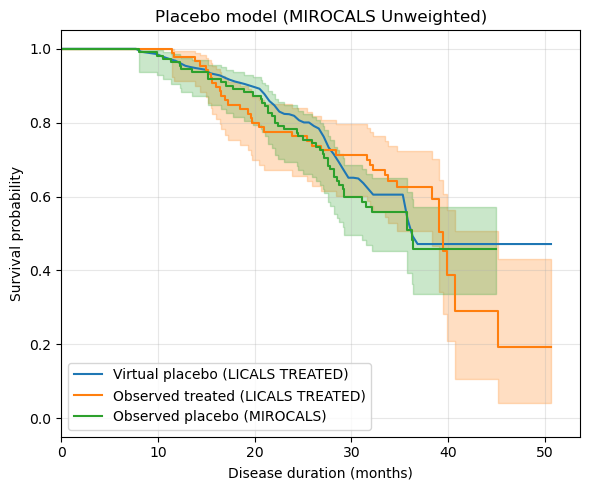

In [957]:
dev_placebo_df = prep_df(dat_set.copy(), covariates, weight_col=weight_col)
obs_treated_df = prep_df(ext_df.copy(), covariates, weight_col=weight_col)
obs_placebo_df = prep_df(dat_set.copy(), covariates, weight_col=weight_col)

model_placebo, dev_placebo_used = fit_cox_model(
    dev_placebo_df,
    covariates=res_strategy.best_vars_full,
    weight_col=weight_col,
    time_col="Disease_Duration",
    event_col="Event",
    robust=True,
)

time_max = max(dev_placebo_used["Disease_Duration"].max(), obs_treated_df["Disease_Duration"].max())
time_grid = np.linspace(0.05, time_max, 100)

shrinkage = uniform_shrinkage_from_slope(res_strategy.slope_corr)

plot_virtual_placebo_vs_treated_and_placebo(
    model_placebo=model_placebo,
    treated_df=obs_treated_df,
    placebo_df=obs_placebo_df,
    vars_final=res_strategy.best_vars_full,
    time_grid=time_grid,
    shrinkage=shrinkage,
    x_max= time_max + 3,
    weight_col=weight_col,
    model_data='(MIROCALS Unweighted)',
    applied_data='LICALS TREATED',
    obs_treated='LICALS TREATED',
    obs_placebo='MIROCALS',
    fig_max = 6,
    fig_min = 5,
)

can you extract all the mathematical expressions and its how and why. make this into a comprehensive lecture note. Also include how the weighting works. make it such that any question i am asked i can answer it. make sure to explain every single fucntion

In [ ]:
# hist_placebo_df = prep_df(dat_set.copy(), covariates, weight_col=weight_col)
# obs_treated_df  = prep_df(ext_df.copy(), covariates, weight_col=weight_col)
# obs_placebo_df  = prep_df(dat_set.copy(), covariates, weight_col=weight_col)

# time_max = hist_placebo_df["Disease_Duration"].max()
# time_max = hist_placebo_df["Disease_Duration"].max()
# time_grid = np.linspace(0.05, time_max, 100)  # avoid 0 exactly sometimes

# print(obs_treated_df.columns)
# print(obs_placebo_df.columns)

In [ ]:
# cal_updated = res_ext["calibration_table_updated"]
# display(tidy_calibration_table(cal_updated))

# fig, ax = plot_calibration_table(
#     cal_updated,
#     title=f"External calibration at {t0_months} months (baseline-updated)",
#     percent=True,
#     show_45deg=True
# )
# plt.show()

In [ ]:
# cal_frozen = res_ext["calibration_table_frozen"]
# display(tidy_calibration_table(cal_frozen))

# fig, ax = plot_calibration_table(
#     cal_frozen,
#     title=f"External calibration at {t0_months} months",
#     percent=True,
#     show_45deg=True
# )
# plt.show()